<a href="https://colab.research.google.com/github/espoirgk/PhD_Repos/blob/main/GroundWater_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow import random
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.pipeline import Pipeline



In [ ]:
df = pd.read_excel("Dataset_ML.xlsx")
df['DateSemih'] = pd.to_datetime(df['DateSemih'])

In [ ]:
df.head(5)

,DateSemih,Rain_mmsemih,P_20m_hPa,Tair_2m_SmallAnt_degC,Rg_estim_20m.Gf,LWdownW.Gf,Diff.Fraction.ModEmpir.Gf,WVC_obs_corrected,Rain_cumul,Rain_cumul_norm_mean
0,2019-01-01 00:15:00,0.0,1010.071949,22.47,-1.042354,370.9,0.405579,0.228656,0.0,0.0
1,2019-01-01 00:45:00,0.0,1009.974449,22.05,-1.091482,376.0,0.411751,0.228633,0.0,0.0
2,2019-01-01 01:15:00,0.0,1009.920463,21.99,-1.115432,378.6,0.414722,0.228609,0.0,0.0
3,2019-01-01 01:45:00,0.0,1009.857707,21.69,-1.086570,381.0,0.412792,0.228585,0.0,0.0
4,2019-01-01 02:15:00,0.0,1009.739213,21.51,-1.059549,377.7,0.414060,0.228561,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DateSemih                  52608 non-null  datetime64[ns]
 1   Rain_mmsemih               52608 non-null  float64       
 2   P_20m_hPa                  52608 non-null  float64       
 3   Tair_2m_SmallAnt_degC      50890 non-null  float64       
 4   Rg_estim_20m.Gf            52608 non-null  float64       
 5   LWdownW.Gf                 52608 non-null  float64       
 6   Diff.Fraction.ModEmpir.Gf  52239 non-null  float64       
 7   WVC_obs_corrected          52608 non-null  float64       
 8   Rain_cumul                 52608 non-null  float64       
 9   Rain_cumul_norm_mean       52608 non-null  float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 4.0 MB


In [ ]:
# Set 'DateSemih' as the index of the DataFrame
df.set_index('DateSemih', inplace=True)

# Resample the data to every 6 hours (6H) and take the mean value within each 6-hour interval to be in adequation with ERA data
resampled_df = df.resample('6H').mean()

# Reset the index to turn the datetime index back into a column
resampled_df.reset_index(inplace=True)

In [ ]:
resampled_df

,DateSemih,Rain_mmsemih,P_20m_hPa,Tair_2m_SmallAnt_degC,Rg_estim_20m.Gf,LWdownW.Gf,Diff.Fraction.ModEmpir.Gf,WVC_obs_corrected,Rain_cumul,Rain_cumul_norm_mean
0,2019-01-01 00:00:00,0.0,1009.668210,20.519167,-1.045118,367.958333,0.410611,0.228526,0.000,0.0
1,2019-01-01 06:00:00,0.0,1010.992771,23.244167,291.718768,367.858333,0.550708,0.228241,0.000,0.0
2,2019-01-01 12:00:00,0.0,1007.991584,36.506667,599.501664,417.766667,0.419951,0.227956,0.000,0.0
3,2019-01-01 18:00:00,0.0,1009.643259,28.759167,3.416804,398.166667,0.491439,0.227671,0.000,0.0
4,2019-01-02 00:00:00,0.0,1010.571412,20.595000,-1.054381,365.450000,0.408407,0.227387,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...
4379,2021-12-30 18:00:00,0.0,1005.774427,25.600833,6.125056,355.483333,0.459472,0.229235,482.377,1.0
4380,2021-12-31 00:00:00,0.0,1006.345022,18.031667,-0.978744,328.783333,0.414292,0.229061,482.377,1.0
4381,2021-12-31 06:00:00,0.0,1007.758719,22.499167,293.804237,338.875000,0.437561,0.228541,482.377,1.0
4382,2021-12-31 12:00:00,0.0,1005.180191,35.763333,609.736652,382.750000,0.357804,0.228425,482.377,1.0


<Axes: >

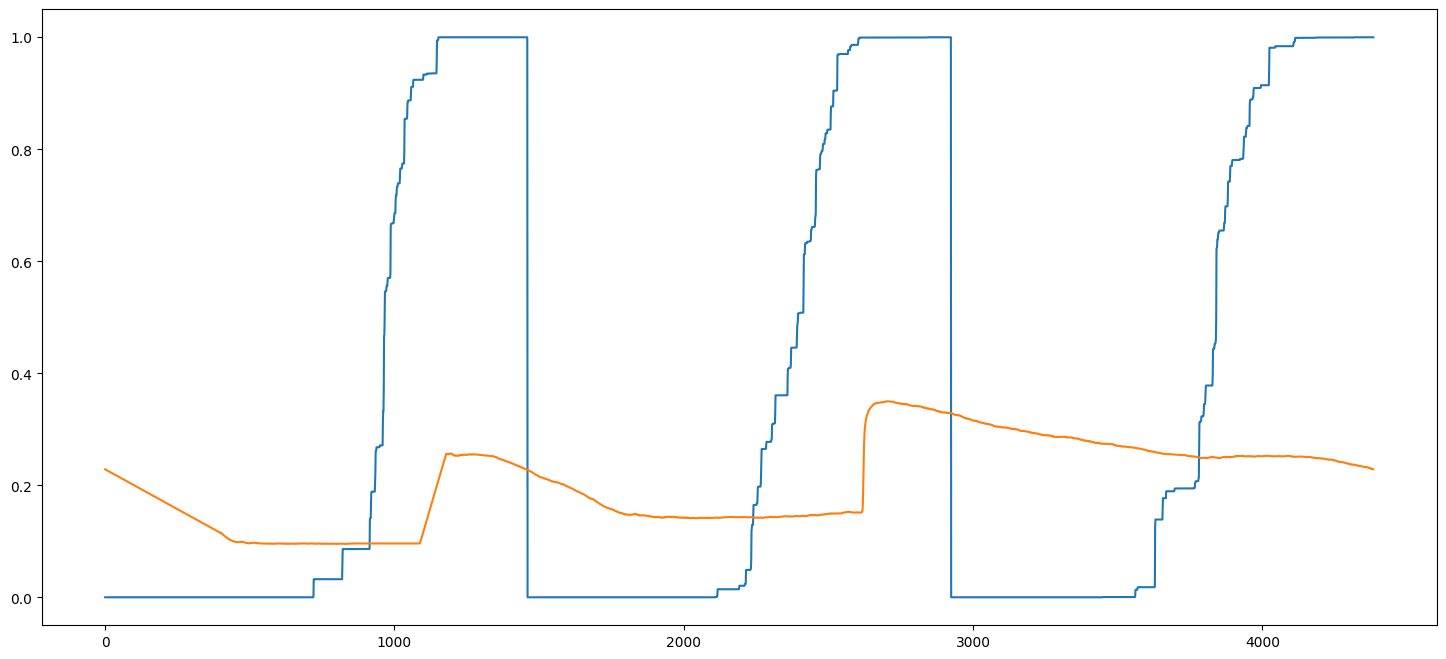

In [ ]:
resampled_df.Rain_cumul_norm_mean.plot()
resampled_df.WVC_obs_corrected.plot()

In [ ]:
resampled_df.corr()

<ipython-input-175-1b917c4a6ed3>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  resampled_df.corr()


,Rain_mmsemih,P_20m_hPa,Tair_2m_SmallAnt_degC,Rg_estim_20m.Gf,LWdownW.Gf,Diff.Fraction.ModEmpir.Gf,WVC_obs_corrected,Rain_cumul,Rain_cumul_norm_mean
Rain_mmsemih,1.000000,0.001242,-0.050866,-0.061001,0.123028,0.045376,-0.065579,0.039536,0.038588
P_20m_hPa,0.001242,1.000000,-0.353348,-0.150598,-0.264713,0.078051,-0.152406,-0.143429,-0.149827
Tair_2m_SmallAnt_degC,-0.050866,-0.353348,1.000000,0.723459,0.652202,-0.192139,-0.028269,0.019673,0.023949
Rg_estim_20m.Gf,-0.061001,-0.150598,0.723459,1.000000,0.385379,-0.317371,-0.040275,-0.062167,-0.061682
LWdownW.Gf,0.123028,-0.264713,0.652202,0.385379,1.000000,0.083290,-0.305506,0.125600,0.133048
Diff.Fraction.ModEmpir.Gf,0.045376,0.078051,-0.192139,-0.317371,0.083290,1.000000,0.030022,0.058653,0.065148
WVC_obs_corrected,-0.065579,-0.152406,-0.028269,-0.040275,-0.305506,0.030022,1.000000,0.331782,0.324971
Rain_cumul,0.039536,-0.143429,0.019673,-0.062167,0.125600,0.058653,0.331782,1.000000,0.992618
Rain_cumul_norm_mean,0.038588,-0.149827,0.023949,-0.061682,0.133048,0.065148,0.324971,0.992618,1.000000


import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_4517078345389778203, *['Rain_mmsemih'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_4517078345389778203, *['P_20m_hPa'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def value_plot(df, y, sort_ascending=False, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  if sort_ascending:
    df = df.sort_values(y).reset_index(drop=True)
  _, ax = plt.subplots(figsize=figsize)
  df[y].plot(kind='line')
  plt.title(y)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(df_4517078345389778203, *['Tair_2m_SmallAnt_degC'], **{})
chart

...

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_4517078345389778203, *['Rain_mmsemih'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_4517078345389778203, *['P_20m_hPa'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_4517078345389778203, *['Tair_2m_SmallAnt_degC'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def histogram(df, colname, num_bins=20, figsize=(2, 1)):
  from matplotlib import pyplot as plt
  _, ax = plt.subplots(figsize=figsize)
  plt.hist(df[colname], bins=num_bins, histtype='stepfilled')
  plt.ylabel('count')
  plt.title(colname)
  ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = histogram(df_4517078345389778203, *['Rg_estim_20m.Gf'], **{})
chart

import numpy as np
from google.colab import autoviz
df_4517078345389778203 = autoviz.get_df('df_4517078345389778203')

def scatter_plots(df, colname_pairs, scatter_plot_size=2.5, size=8, alpha=.6):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * scatter_plot_size, scatter_plot_size))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    ax.scatter(df[x_colname], df[y_colname], s=size, alpha=alpha)
    plt.xlabel(x_colname)
    plt.ylabel(y_colname)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(df_4517078345389778203, *[[['Rain_mmsemih', 'P_20m_hPa'], ['P_20m_hPa', 'Tair_2m_SmallAnt_degC'], ['Tair_2m_SmallAnt_degC', 'Rg_estim_20m.Gf'], ['Rg_estim_20m.Gf', 'LWdownW.Gf']]], **{})
chart

In [ ]:
# Combine 'DateSemih' with 'y_test' and 'gb_predictions' into a new DataFrame
df_predictions = pd.DataFrame({'DateSemih': df.loc[y_test.index, 'DateSemih'], 'Actual': y_test, 'Predictions': gb_predictions})

# Convert 'DateSemih' column to pandas datetime type
df_predictions['DateSemih'] = pd.to_datetime(df_predictions['DateSemih'])

# Set 'DateSemih' as the index
df_predictions = df_predictions.set_index('DateSemih')

In [ ]:
train =  pd.DataFrame({'DateSemih': df.loc[y_test.index, 'DateSemih'], 'Actual': y_train})
#train = train.set_index('DateSemih')

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [ ]:
# Set a random seed for reproducibility
np.random.seed(42)
random.set_seed(42)

# Load the dataset (replace 'your_dataset.csv' with the actual filename)
data = resampled_df.copy()

# Drop unnecessary columns (DateSemih and Rain_cumul_norm_mean in this case)
data = data.drop(columns=['DateSemih'])

# Split the data into features (X) and target (y)
X = data.drop(columns=['WVC_obs_corrected'])
y = data['WVC_obs_corrected']


**Publis: **

1.   https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2016WR019933
2.   https://www.mdpi.com/1999-4893/13/11/300
3.   https://link.springer.com/article/10.1007/s11269-020-02704-3





In [ ]:

###Calibration

In [ ]:

# Feature scaling (optional but can improve some models)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Impute missing values with the mean of the corresponding feature
imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

# Define models and their names
models = [
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('Support Vector Regression', SVR(kernel='linear')),
    ('Regression', LinearRegression()),
    ('XGBoost', XGBRegressor(n_estimators=100, random_state=42))
]

# Perform KFold cross-validation and store results in a dictionary
cv = KFold(n_splits=10, random_state=1, shuffle=True)
results = {}
for name, model in models:
    mse_scores = -cross_val_score(model, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
    r2_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')
    results[name] = {
        'MSE': np.mean(mse_scores),
        'R^2': np.mean(r2_scores)
    }

# Convert the results dictionary to a DataFrame
metrics_df = pd.DataFrame.from_dict(results, orient='index')

# Print the results

print(metrics_df)


                                MSE       R^2
Random Forest              0.001141  0.801667
Gradient Boosting          0.001939  0.662919
Support Vector Regression  0.005017  0.127476
Regression                 0.003868  0.327333
XGBoost                    0.001139  0.801807


#Optimization

In [ ]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipelines for both models
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Impute missing values
    ('scaler', StandardScaler()),                 # Optional: Scale the features
    ('rf', RandomForestRegressor(random_state=42))
])

xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Impute missing values
    ('scaler', StandardScaler()),                 # Optional: Scale the features
    ('xgb', XGBRegressor(random_state=42))
])

# Define the parameter grids for GridSearch
rf_param_grid = {
    'rf__n_estimators': [50, 100, 150],    # Number of trees in the forest
    'rf__max_depth': [None, 5, 10],        # Maximum depth of the trees
}

xgb_param_grid = {
    'xgb__n_estimators': [50, 100, 150],    # Number of boosting rounds
    'xgb__max_depth': [3, 5, 7],            # Maximum depth of the trees
}

# Perform GridSearchCV for Random Forest and XGBoost models
rf_grid = GridSearchCV(rf_pipe, param_grid=rf_param_grid, cv=cv, scoring='neg_mean_squared_error')
rf_grid.fit(X_train, y_train)

xgb_grid = GridSearchCV(xgb_pipe, param_grid=xgb_param_grid, cv=cv, scoring='neg_mean_squared_error')
xgb_grid.fit(X_train, y_train)

# Get the best models and their respective results
best_rf_model = rf_grid.best_estimator_
best_rf_mse = -rf_grid.best_score_
best_rf_r2 = rf_grid.best_estimator_.score(X_test, y_test)

best_xgb_model = xgb_grid.best_estimator_
best_xgb_mse = -xgb_grid.best_score_
best_xgb_r2 = xgb_grid.best_estimator_.score(X_test, y_test)

# Compare the results
print("Best Random Forest - MSE:", best_rf_mse, "R^2:", best_rf_r2)
print("Best XGBoost - MSE:", best_xgb_mse, "R^2:", best_xgb_r2)


Best Random Forest - MSE: 0.0012269415601006291 R^2: 0.7934590287797592
Best XGBoost - MSE: 0.0012228646386213435 R^2: 0.7994641149159013


In [ ]:
best_xgb_model

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, gpu_id=None,
                              grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, n_estimators=150,
                              n_jobs=None, num_parallel_tree=None,
                              predictor=None, random_state=42, ...))])

**Boostrapping**

In [ ]:
from sklearn.utils import resample

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Feature scaling (optional but can improve some models)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Impute missing values with the mean of the corresponding feature
imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)



# Model 1: Random Forest
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = xgb_model.predict(X_test_scaled)

# Calculate the mean squared error for the predictions
mse = mean_squared_error(y_test, y_pred)

# Bootstrapping to calculate prediction intervals
n_bootstraps = 1000  # Number of bootstrap samples
bootstrap_predictions = np.zeros((len(X_test_scaled), n_bootstraps))

for i in range(n_bootstraps):
    # Create a bootstrap sample with replacement
    X_bootstrap, y_bootstrap = resample(X_test_scaled, y_pred, random_state=i)

    # Make predictions on the bootstrap sample
    bootstrap_predictions[:, i] = xgb_model.predict(X_bootstrap)

# Calculate the 95% prediction interval (2.5th and 97.5th percentiles)
lower_bound = np.percentile(bootstrap_predictions, 2.5, axis=1)
upper_bound = np.percentile(bootstrap_predictions, 97.5, axis=1)

# Print the mean squared error and prediction intervals
print("Mean Squared Error:", mse)
print("Lower Bound (95%):", lower_bound)
print("Upper Bound (95%):", upper_bound)


In [ ]:

# Feature scaling (optional but can improve some models)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Impute missing values with the mean of the corresponding feature
imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [ ]:

# Model 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
rf_mse = -np.mean(rf_cv_scores)
rf_r2 = np.mean(cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='r2'))


# Model 6: XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
xgb_mse = -np.mean(xgb_cv_scores)
xgb_r2 = np.mean(cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring='r2'))

# Compare the results
print("Random Forest - MSE:", rf_mse, "R^2:", rf_r2)
print("XGBoost - MSE:", xgb_mse, "R^2:", xgb_r2)


In [ ]:
#Test validation

In [ ]:
# Create a dictionary to store results
results_dict = {
    'Date': resampled_df.loc[y_test.index, 'DateSemih'],
    'True_Values': y_test,
    'Predicted_Values': y_pred
}

# Convert the dictionary into a DataFrame
results_df = pd.DataFrame(results_dict)
results_df = results_df.set_index("Date")
# Print the DataFrame
results_df ['Year'] = results_df.index.year
print(results_df)

                     True_Values  Predicted_Values  Year
Date                                                    
2019-06-17 12:00:00     0.095865          0.127857  2019
2020-08-27 06:00:00     0.144626          0.106990  2020
2019-05-30 00:00:00     0.096122          0.193074  2019
2020-10-19 06:00:00     0.315662          0.171305  2020
2019-12-15 18:00:00     0.241377          0.250544  2019
...                          ...               ...   ...
2019-03-06 00:00:00     0.155618          0.198673  2019
2021-09-20 00:00:00     0.251206          0.227549  2021
2019-09-22 06:00:00     0.096096          0.127489  2019
2021-01-05 06:00:00     0.325652          0.316654  2021
2021-04-04 12:00:00     0.286071          0.238976  2021

[877 rows x 3 columns]


In [ ]:
r_squared = r2_score(y_test, y_pred)

<Figure size 400x400 with 0 Axes>

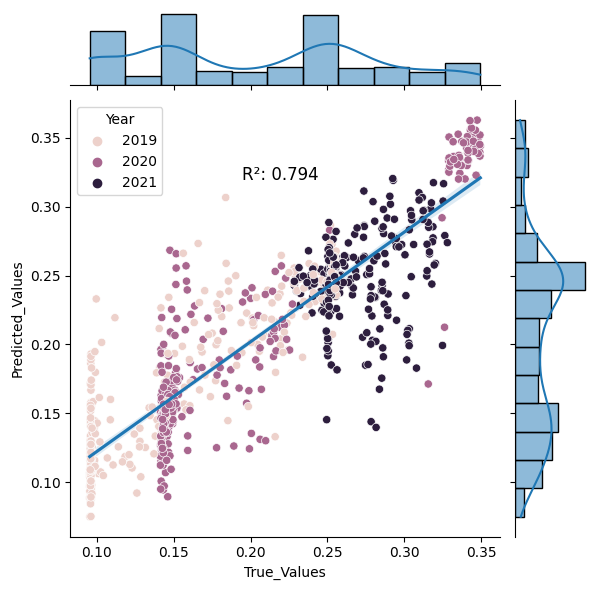

In [ ]:
plt.figure(figsize=(4,4))
g = sns.jointplot(x = "True_Values",
            y = "Predicted_Values",
            data = results_df, kind='reg', scatter = False)
sns.scatterplot(x = "True_Values",
            y = "Predicted_Values",
            data = results_df, hue="Year", ax=g.ax_joint)
plt.text(0.4, 0.85, f"R²: {r_squared:.3f}", fontsize=12, ha='left', va='top', transform=plt.gca().transAxes)

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_predict

In [ ]:

y_pred_cv = cross_val_predict(xgb_model, X_scaled, y, cv=cv)

# Create a DataFrame to store the results
best_model_df = pd.DataFrame({
    'Date': resampled_df.loc[y.index, 'DateSemih'],
    'True_Values': y,
    'Predicted_Values': y_pred_cv,

})

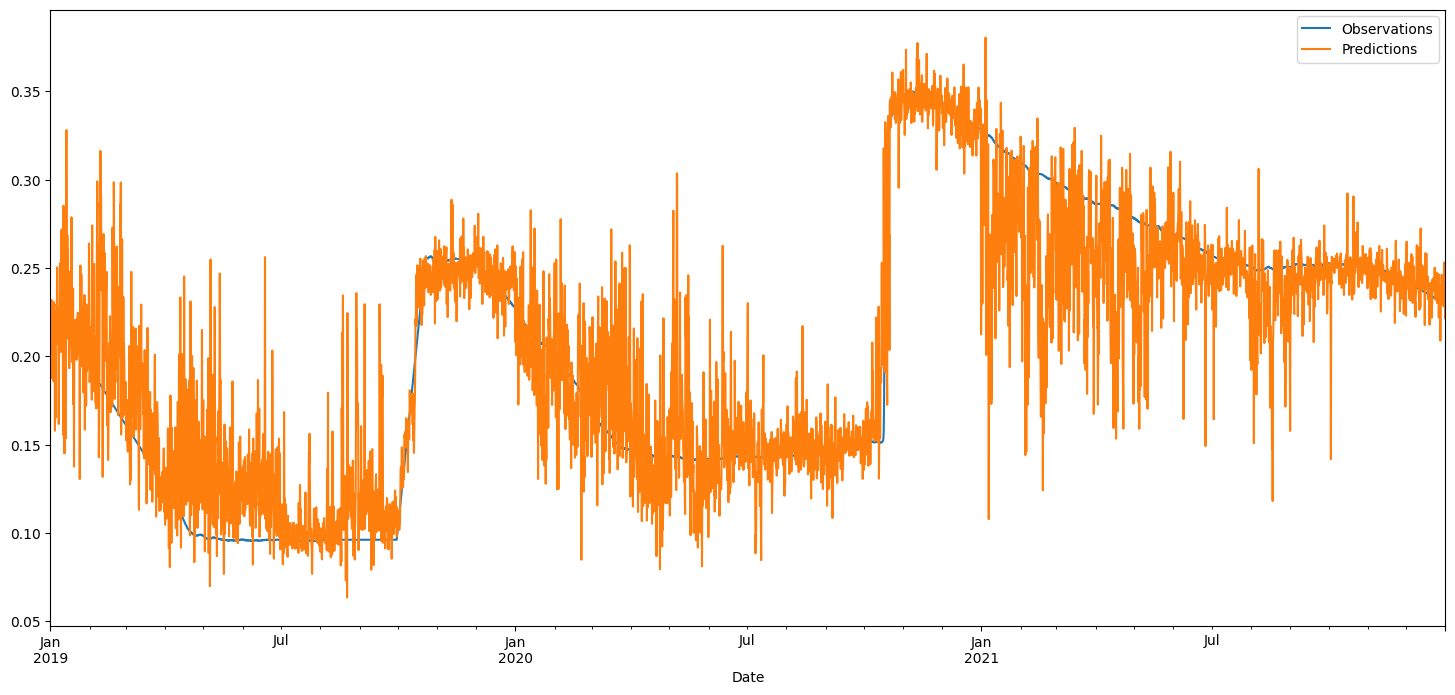

In [ ]:
best_model_df = best_model_df.set_index("Date")
best_model_df['True_Values'].plot(label="Observations")
best_model_df['Predicted_Values'].plot(label="Predictions")
plt.legend()

In [ ]:
results_df['True_Values'].plot()
results_df['Predicted_Values'].plot()
plt.fill_between(results_df.index, lower_bound, upper_bound, color='orange', alpha=0.3, label='Prediction Intervals (95%)')

**Test LSTM**: pour voir si le modèle est amélioré

In [ ]:

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (optional but can improve some models)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Impute missing values with the mean of the corresponding feature
imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)


# Model 4: LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
lstm_model.add(Dense(1))
lstm_model.compile(loss='mse', optimizer='adam')
lstm_model.fit(X_train_lstm, y_train, epochs=100, batch_size=32, verbose=0)
lstm_predictions = lstm_model.predict(X_test_lstm).flatten()
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_r2 = r2_score(y_test, lstm_predictions)

print("LSTM - MSE:", lstm_mse, "R^2:", lstm_r2)

28/28 [==============================] - 0s 3ms/step
LSTM - MSE: 0.0025589266048170103 R^2: 0.5565970849019659
